In [ ]:
# Clone your repo and setup path
!git clone https://github.com/ksushrut/CoinClassifier.git
import sys
sys.path.append("/content/CoinClassifier")

# Import your custom loader
from dataloader import load_coin_dataset
csv_path = 'https://raw.githubusercontent.com/ksushrut/CoinClassifier/refs/heads/main/processed_data.csv'

# Load using your defined split logic (60/10/30)
train_df, val_df, test_df, train_loader, val_loader, test_loader = load_coin_dataset(csv_path)

Cloning into 'CoinClassifier'...
remote: Enumerating objects: 216, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (73/73), done.
remote: Total 216 (delta 44), reused 6 (delta 6), pack-reused 137 (from 1)
Receiving objects: 100% (216/216), 29.40 MiB | 29.57 MiB/s, done.
Resolving deltas: 100% (108/108), done.
                                                    URL image name  \
1048  /content/drive/My Drive/CoinImages/Preprocesse...   18h.jpeg   
951   /content/drive/My Drive/CoinImages/Preprocesse...   21h.jpeg   
2028  /content/drive/My Drive/CoinImages/Preprocesse...   11h.jpeg   
2099  /content/drive/My Drive/CoinImages/Preprocesse...   13t.jpeg   
1162  /content/drive/My Drive/CoinImages/Preprocesse...    19h.jpg   
...                                                 ...        ...   
771   /content/drive/My Drive/CoinImages/Preprocesse...     8t.jpg   
503   /content/drive/My Drive/CoinImages/Preprocesse...   23t.jpeg   
1224  /content/drive/

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Strip labels before encoding
for df in [train_df, val_df, test_df]:
    df['label'] = df['label'].str.strip()

label_encoder = LabelEncoder()
train_df['encoded_class'] = label_encoder.fit_transform(train_df['label'])
val_df['encoded_class'] = label_encoder.transform(val_df['label'])
test_df['encoded_class'] = label_encoder.transform(test_df['label'])

class_names = label_encoder.classes_
num_classes = len(class_names)

print(f"Total Classes: {num_classes}")
print("Class Names:", list(class_names))

Total Classes: 48
Class Names: ['1 Nepali Paisa', '1 Nepali Rupee', '1 Yen', '1 cent', '1 dollar', '10 Yen', '10 cents', '100 Yen', '2 Nepali Rupee', '2 dollars', '25 Nepali Paisa', '25 cents', '5 Nepali Rupee', '5 Yen', '5 cents', '50 Yen', '50 cents', '500 Yen', 'AUD 1 Dollar', 'AUD 10 Cents', 'AUD 2 Dollar', 'AUD 20 Cents', 'AUD 5 Cents', 'AUD 50 Cents', 'GBP 1 Penny', 'GBP 1 Pound', 'GBP 10 Pence', 'GBP 2 Pence', 'GBP 2 Pound', 'GBP 20 Pence', 'GBP 5 Pence', 'GBP 50 Pence', 'INR 10Rs', 'INR 1Re', 'INR 20Rs', 'INR 2Rs', 'INR 5Rs', 'NZ 10 c', 'NZ 20 c', 'NZ 50 c', 'NZ Dollar 1', 'NZ Dollar 2', 'USD 1$', 'USD 10¢', 'USD 1¢', 'USD 25¢', 'USD 50¢', 'USD 5¢']



Train Set:
label
1 Nepali Paisa     30
1 Nepali Rupee     30
1 Yen              30
1 cent             30
1 dollar           30
10 Yen             30
10 cents           30
100 Yen            30
2 Nepali Rupee     30
2 dollars          30
25 Nepali Paisa    30
25 cents           30
5 Nepali Rupee     30
5 Yen              30
5 cents            31
50 Yen             30
50 cents           30
500 Yen            30
AUD 1 Dollar       30
AUD 10 Cents       30
AUD 2 Dollar       31
AUD 20 Cents       30
AUD 5 Cents        31
AUD 50 Cents       31
GBP 1 Penny        30
GBP 1 Pound        31
GBP 10 Pence       31
GBP 2 Pence        30
GBP 2 Pound        31
GBP 20 Pence       35
GBP 5 Pence        31
GBP 50 Pence       31
INR 10Rs           29
INR 1Re            30
INR 20Rs           30
INR 2Rs            30
INR 5Rs            30
NZ 10 c            30
NZ 20 c            30
NZ 50 c            30
NZ Dollar 1        30
NZ Dollar 2        30
USD 1$             30
USD 10¢            30
USD 1¢        

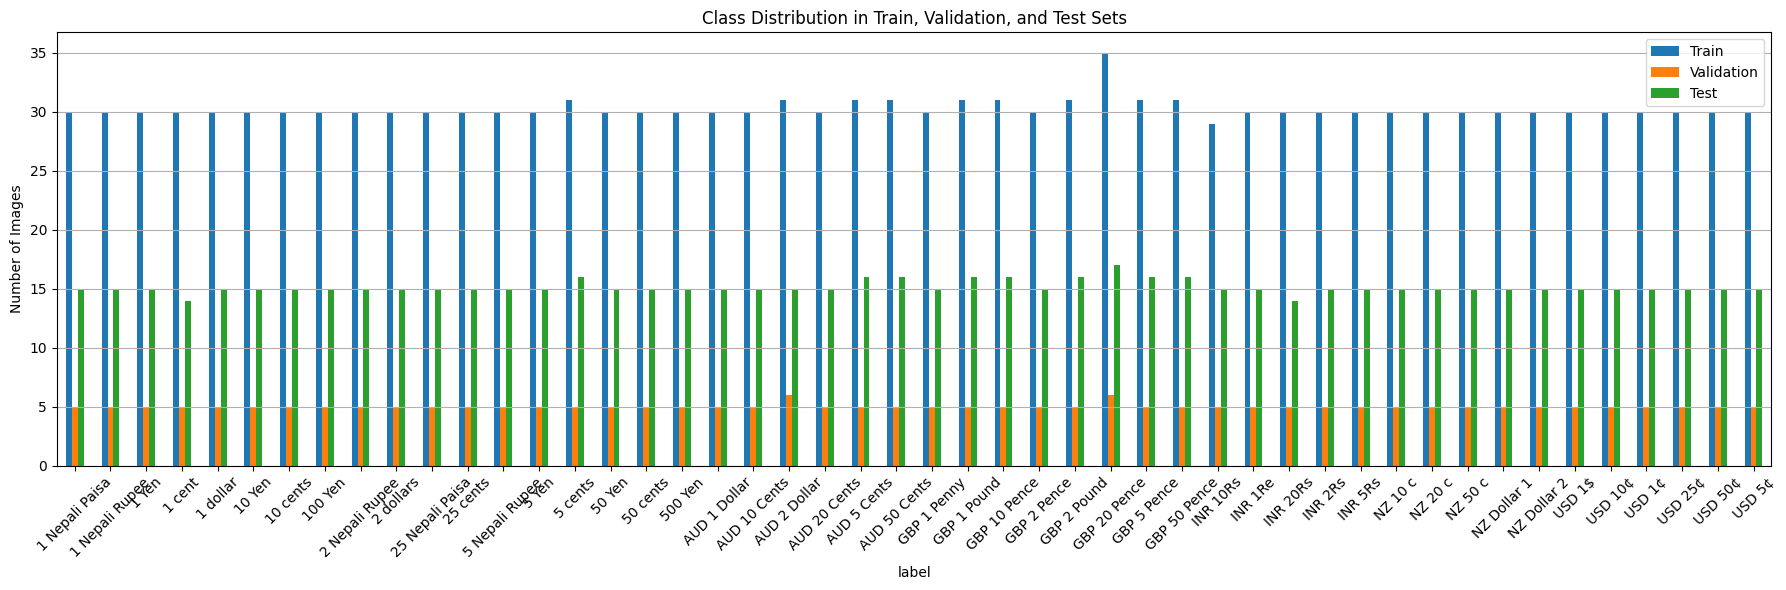

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def show_distribution(df, name):
    print(f"\n{name} Set:")
    print(df['label'].value_counts().sort_index())
    return df['label'].value_counts().sort_index()

train_counts = show_distribution(train_df, "Train")
val_counts = show_distribution(val_df, "Validation")
test_counts = show_distribution(test_df, "Test")

# Combine counts for visualization
dist_df = pd.DataFrame({
    'Train': train_counts,
    'Validation': val_counts,
    'Test': test_counts
}).fillna(0)

# Bar chart
dist_df.plot(kind='bar', figsize=(18, 6))
plt.title("Class Distribution in Train, Validation, and Test Sets")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [ ]:
# Show unique countries in each split
print(" Unique Countries in Train Set:")
print(sorted(train_df['country'].unique()))

print("\n Unique Countries in Validation Set:")
print(sorted(val_df['country'].unique()))

print("\n Unique Countries in Test Set:")
print(sorted(test_df['country'].unique()))

# Optional: all combined
all_countries = set(train_df['country']) | set(val_df['country']) | set(test_df['country'])
print("\n All Unique Countries Across All Sets:")
print(sorted(all_countries))


 Unique Countries in Train Set:
['Australia', 'Canada', 'India', 'Japan', 'Nepal', 'New Zealand', 'United Kingdom', 'United States']

 Unique Countries in Validation Set:
['Australia', 'Canada', 'India', 'Japan', 'Nepal', 'New Zealand', 'United Kingdom', 'United States']

 Unique Countries in Test Set:
['Australia', 'Canada', 'India', 'Japan', 'Nepal', 'New Zealand', 'United Kingdom', 'United States']

 All Unique Countries Across All Sets:
['Australia', 'Canada', 'India', 'Japan', 'Nepal', 'New Zealand', 'United Kingdom', 'United States']


In [ ]:
# Define the countries to keep
selected_countries = ['Japan', 'Canada', 'United Kingdom']

# Filter each dataset
japan_canada_uk_train_df = train_df[train_df['country'].isin(selected_countries)].reset_index(drop=True)
japan_canada_uk_val_df = val_df[val_df['country'].isin(selected_countries)].reset_index(drop=True)
japan_canada_uk_test_df = test_df[test_df['country'].isin(selected_countries)].reset_index(drop=True)

# Print sample counts to verify
print(" Filtered Dataset Sizes:")
print("Train:", len(japan_canada_uk_train_df))
print("Validation:", len(japan_canada_uk_val_df))
print("Test:", len(japan_canada_uk_test_df))


 Filtered Dataset Sizes:
Train: 641
Validation: 106
Test: 322


In [ ]:
print("\nTrain countries:", japan_canada_uk_train_df['country'].unique())
print("Validation countries:", japan_canada_uk_val_df['country'].unique())
print("Test countries:", japan_canada_uk_test_df['country'].unique())



Train countries: ['United Kingdom' 'Canada' 'Japan']
Validation countries: ['Canada' 'United Kingdom' 'Japan']
Test countries: ['Canada' 'United Kingdom' 'Japan']


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Strip any extra spaces from labels
for df in [japan_canada_uk_train_df, japan_canada_uk_val_df, japan_canada_uk_test_df]:
    df['label'] = df['label'].str.strip()

# Fit label encoder
label_encoder = LabelEncoder()
japan_canada_uk_train_df['encoded_class'] = label_encoder.fit_transform(japan_canada_uk_train_df['label'])
japan_canada_uk_val_df['encoded_class'] = label_encoder.transform(japan_canada_uk_val_df['label'])
japan_canada_uk_test_df['encoded_class'] = label_encoder.transform(japan_canada_uk_test_df['label'])

class_names = label_encoder.classes_
num_classes = len(class_names)


In [ ]:
from dataloader import CoinImageDataset
from torch.utils.data import DataLoader

train_dataset = CoinImageDataset(japan_canada_uk_train_df)
val_dataset = CoinImageDataset(japan_canada_uk_val_df)
test_dataset = CoinImageDataset(japan_canada_uk_test_df)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


# **ResNet18: Last 2 Blocks + FC + CosineAnnealingLR**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torchvision.models import ResNet18_Weights
from tqdm import tqdm
from sklearn.metrics import classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Model Setup ===
print("\n--- ResNet18: Last 2 Blocks + FC + CosineAnnealingLR ---")
resnet_part = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

# Replace final classifier layer
resnet_part.fc = nn.Linear(resnet_part.fc.in_features, num_classes)

# Freeze all layers initially
for param in resnet_part.parameters():
    param.requires_grad = False

# Unfreeze layer3, layer4, and fc
for name, param in resnet_part.named_parameters():
    if "layer3" in name or "layer4" in name or "fc" in name:
        param.requires_grad = True

resnet_part = resnet_part.to(device)

# Optimizer only for unfrozen layers
trainable_params = filter(lambda p: p.requires_grad, resnet_part.parameters())
optimizer_part = optim.Adam(trainable_params, lr=0.001)

# CosineAnnealingLR scheduler
scheduler_part = optim.lr_scheduler.CosineAnnealingLR(optimizer_part, T_max=10)

criterion = nn.CrossEntropyLoss()

# === Training Function ===
def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)

        for inputs, labels in loop:
            inputs, labels = inputs.to(device), labels.to(device)

            # Normalize using ImageNet stats
            mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
            std = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)
            inputs = (inputs - mean) / std

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            loop.set_postfix(loss=loss.item(), acc=correct / total)

        scheduler.step()
        train_loss = running_loss / total
        train_acc = correct / total
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                inputs = (inputs - mean) / std
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * inputs.size(0)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
              f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

    return model, history

# === Train the model ===
resnet_part, history_resnet_part = train_model(
    model=resnet_part,
    criterion=criterion,
    optimizer=optimizer_part,
    scheduler=scheduler_part,
    num_epochs=10
)

# === Evaluation ===
misclassified_samples = []

def evaluate_model(model, test_loader, class_names, test_df):
    model.eval()
    all_preds, all_labels, all_indices = [], [], []

    with torch.no_grad():
        for batch_idx, (inputs, labels) in enumerate(test_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            batch_start = batch_idx * test_loader.batch_size
            indices = list(range(batch_start, batch_start + inputs.size(0)))
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_indices.extend(indices)

    # Attach to test_df
    test_df = test_df.iloc[all_indices].copy()
    test_df['predicted'] = all_preds
    test_df['correct'] = test_df['encoded_class'] == test_df['predicted']

    print("\nClassification Report:\n")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    return test_df



--- ResNet18: Last 2 Blocks + FC + CosineAnnealingLR ---


Epoch 1: Train Loss=1.0583, Train Acc=0.6958, Val Loss=1.0916, Val Acc=0.7170


Epoch 2: Train Loss=0.4316, Train Acc=0.8697, Val Loss=0.7458, Val Acc=0.8019


Epoch 3: Train Loss=0.2173, Train Acc=0.9337, Val Loss=0.5566, Val Acc=0.8113


Epoch 4: Train Loss=0.1679, Train Acc=0.9524, Val Loss=0.3541, Val Acc=0.8774


...

Epoch 6: Train Loss=0.1223, Train Acc=0.9633, Val Loss=0.4079, Val Acc=0.8679


Epoch 7: Train Loss=0.0765, Train Acc=0.9797, Val Loss=0.3888, Val Acc=0.8679


Epoch 8: Train Loss=0.0443, Train Acc=0.9844, Val Loss=0.4250, Val Acc=0.8774


Epoch 9: Train Loss=0.0299, Train Acc=0.9891, Val Loss=0.4045, Val Acc=0.8868


Epoch 10: Train Loss=0.0305, Train Acc=0.9938, Val Loss=0.4418, Val Acc=0.8774


In [ ]:
# Run evaluation
evaluated_df = evaluate_model(resnet_part, test_loader, class_names, japan_canada_uk_test_df)


Classification Report:

              precision    recall  f1-score   support

       1 Yen       0.76      0.87      0.81        15
      1 cent       1.00      0.14      0.25        14
    1 dollar       0.77      0.67      0.71        15
      10 Yen       1.00      0.67      0.80        15
    10 cents       0.75      1.00      0.86        15
     100 Yen       0.68      1.00      0.81        15
   2 dollars       1.00      0.87      0.93        15
    25 cents       0.91      0.67      0.77        15
       5 Yen       1.00      1.00      1.00        15
     5 cents       0.33      0.94      0.49        16
      50 Yen       0.94      1.00      0.97        15
    50 cents       1.00      0.07      0.12        15
     500 Yen       0.91      0.67      0.77        15
 GBP 1 Penny       0.71      0.33      0.45        15
 GBP 1 Pound       0.36      0.88      0.51        16
GBP 10 Pence       1.00      0.31      0.48        16
 GBP 2 Pence       1.00      0.60      0.75        15
 G

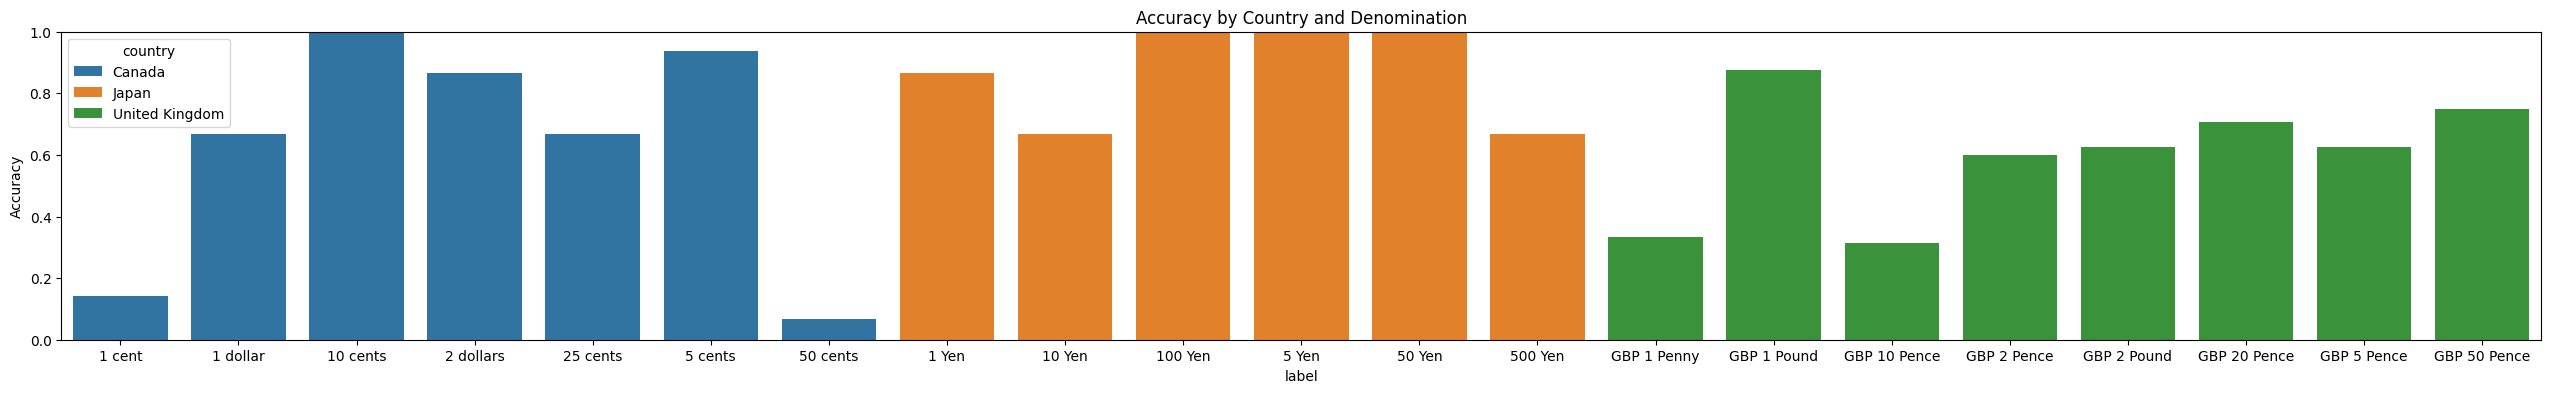

In [ ]:
# 1. Barplot: Accuracy by Country and Denomination
import seaborn as sns
import matplotlib.pyplot as plt

group_acc = evaluated_df.groupby(['country', 'label'])['correct'].value_counts().unstack().fillna(0)
group_acc['accuracy'] = group_acc[True] / (group_acc[True] + group_acc[False])

plt.figure(figsize=(32, 4))
sns.barplot(data=group_acc.reset_index(), x='label', y='accuracy', hue='country')
plt.title("Accuracy by Country and Denomination")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

Actual: 1 cent, Predicted: 1 dollar, Country: Canada, label: 1 cent


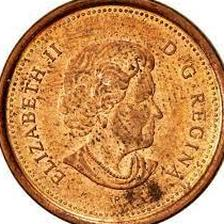

Actual: GBP 10 Pence, Predicted: GBP 5 Pence, Country: United Kingdom, label: GBP 10 Pence


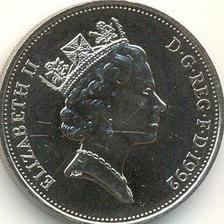

Actual: GBP 50 Pence, Predicted: GBP 2 Pound, Country: United Kingdom, label: GBP 50 Pence


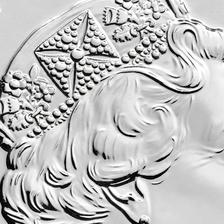

In [ ]:
from PIL import Image
from IPython.display import display

misclassified = evaluated_df[~evaluated_df['correct']].head(3)

for _, row in misclassified.iterrows():
    img_path = row['URL'] + '/' + str(row['image name']).strip()
    img = Image.open(img_path)
    print(f"Actual: {class_names[row['encoded_class']]}, Predicted: {class_names[row['predicted']]}, Country: {row['country']}, label: {row['label']}")
    display(img)

# **ResNet18: Full Fine-tune + ReduceLROnPlateau**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torchvision.models import ResNet18_Weights
from tqdm import tqdm
from sklearn.metrics import classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Model Setup ===
print("\n--- ResNet18: Full Fine-tune + ReduceLROnPlateau ---")
resnet_full = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

# Replace final classifier layer
resnet_full.fc = nn.Linear(resnet_full.fc.in_features, num_classes)
resnet_full = resnet_full.to(device)

# All layers are trainable by default (fine-tune everything)
optimizer_full = optim.Adam(resnet_full.parameters(), lr=0.001)

# Use ReduceLROnPlateau scheduler
scheduler_full = optim.lr_scheduler.ReduceLROnPlateau(optimizer_full, mode='min', factor=0.5, patience=2, verbose=True)

criterion = nn.CrossEntropyLoss()

# === Training Function with ReduceLROnPlateau ===
def train_model_plateau(model, criterion, optimizer, scheduler, num_epochs=10):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)

        for inputs, labels in loop:
            inputs, labels = inputs.to(device), labels.to(device)

            # Normalize using ImageNet stats
            mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
            std = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)
            inputs = (inputs - mean) / std

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            loop.set_postfix(loss=loss.item(), acc=correct / total)

        train_loss = running_loss / total
        train_acc = correct / total
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        # Validation phase
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                inputs = (inputs - mean) / std
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * inputs.size(0)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        scheduler.step(val_loss)  # Important for ReduceLROnPlateau

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
              f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

    return model, history

# === Train the model ===
resnet_full, history_resnet_full = train_model_plateau(
    model=resnet_full,
    criterion=criterion,
    optimizer=optimizer_full,
    scheduler=scheduler_full,
    num_epochs=10
)




--- ResNet18: Full Fine-tune + ReduceLROnPlateau ---


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1: Train Loss=1.2605, Train Acc=0.6225, Val Loss=0.9646, Val Acc=0.6887


Epoch 2: Train Loss=0.5424, Train Acc=0.8222, Val Loss=1.0686, Val Acc=0.6981


Epoch 3: Train Loss=0.3913, Train Acc=0.8760, Val Loss=1.1547, Val Acc=0.7264


...

Epoch 6: Train Loss=0.2519, Train Acc=0.9204, Val Loss=1.2233, Val Acc=0.7830


Epoch 7: Train Loss=0.2176, Train Acc=0.9228, Val Loss=0.9786, Val Acc=0.8113


Epoch 8: Train Loss=0.1419, Train Acc=0.9540, Val Loss=0.6405, Val Acc=0.8585


Epoch 9: Train Loss=0.0712, Train Acc=0.9805, Val Loss=0.6995, Val Acc=0.8774


Epoch 10: Train Loss=0.0734, Train Acc=0.9735, Val Loss=0.6808, Val Acc=0.8491


In [ ]:
import pandas as pd

def get_evaluation_df(model, test_loader, class_df):
    model.eval()
    rows = []

    with torch.no_grad():
        for idx, (inputs, labels) in enumerate(test_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            if hasattr(outputs, 'logits'):
                outputs = outputs.logits
            _, preds = torch.max(outputs, 1)

            for i in range(len(labels)):
                row = {
                    'true_label': labels[i].item(),
                    'pred_label': preds[i].item(),
                    'correct': preds[i].item() == labels[i].item()
                }
                rows.append(row)

    result_df = pd.DataFrame(rows)
    result_df = pd.concat([result_df, class_df.reset_index(drop=True)], axis=1)
    return result_df

In [ ]:
evaluated_df = evaluate_model(resnet_full, test_loader, class_names, japan_canada_uk_test_df)


Classification Report:

              precision    recall  f1-score   support

       1 Yen       1.00      1.00      1.00        15
      1 cent       1.00      0.86      0.92        14
    1 dollar       1.00      0.93      0.97        15
      10 Yen       1.00      1.00      1.00        15
    10 cents       1.00      0.93      0.97        15
     100 Yen       0.94      1.00      0.97        15
   2 dollars       1.00      1.00      1.00        15
    25 cents       0.94      1.00      0.97        15
       5 Yen       1.00      1.00      1.00        15
     5 cents       0.67      1.00      0.80        16
      50 Yen       0.94      1.00      0.97        15
    50 cents       1.00      0.40      0.57        15
     500 Yen       1.00      1.00      1.00        15
 GBP 1 Penny       0.73      0.73      0.73        15
 GBP 1 Pound       0.65      0.81      0.72        16
GBP 10 Pence       0.91      0.62      0.74        16
 GBP 2 Pence       0.75      0.80      0.77        15
 G

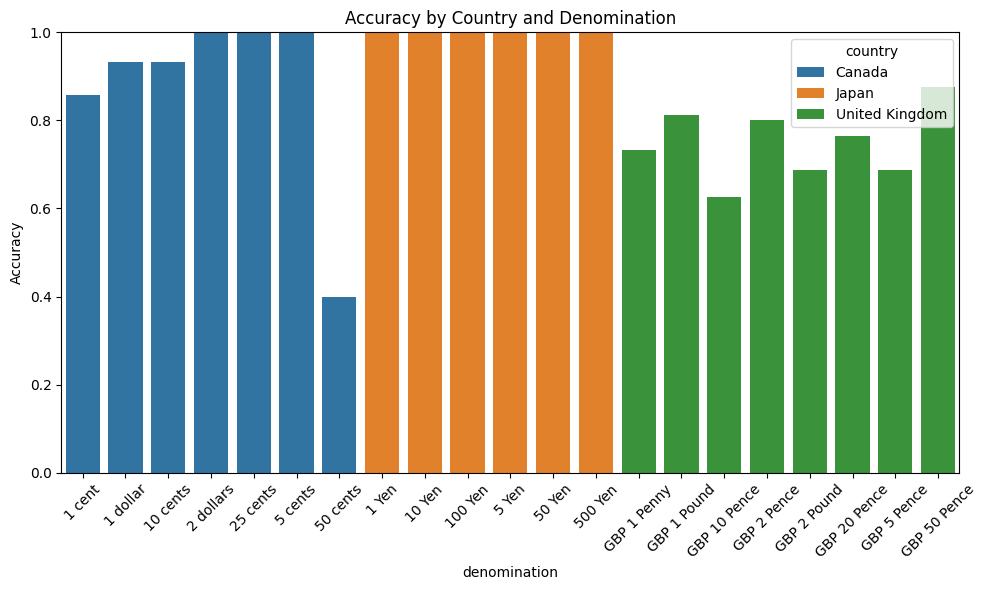

In [ ]:
group_acc = evaluated_df.groupby(['country', 'label'])['correct'].value_counts().unstack().fillna(0)
group_acc['accuracy'] = group_acc[True] / (group_acc[True] + group_acc[False])

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(data=group_acc.reset_index(), x='label', y='accuracy', hue='country')
plt.title("Accuracy by Country and Denomination")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

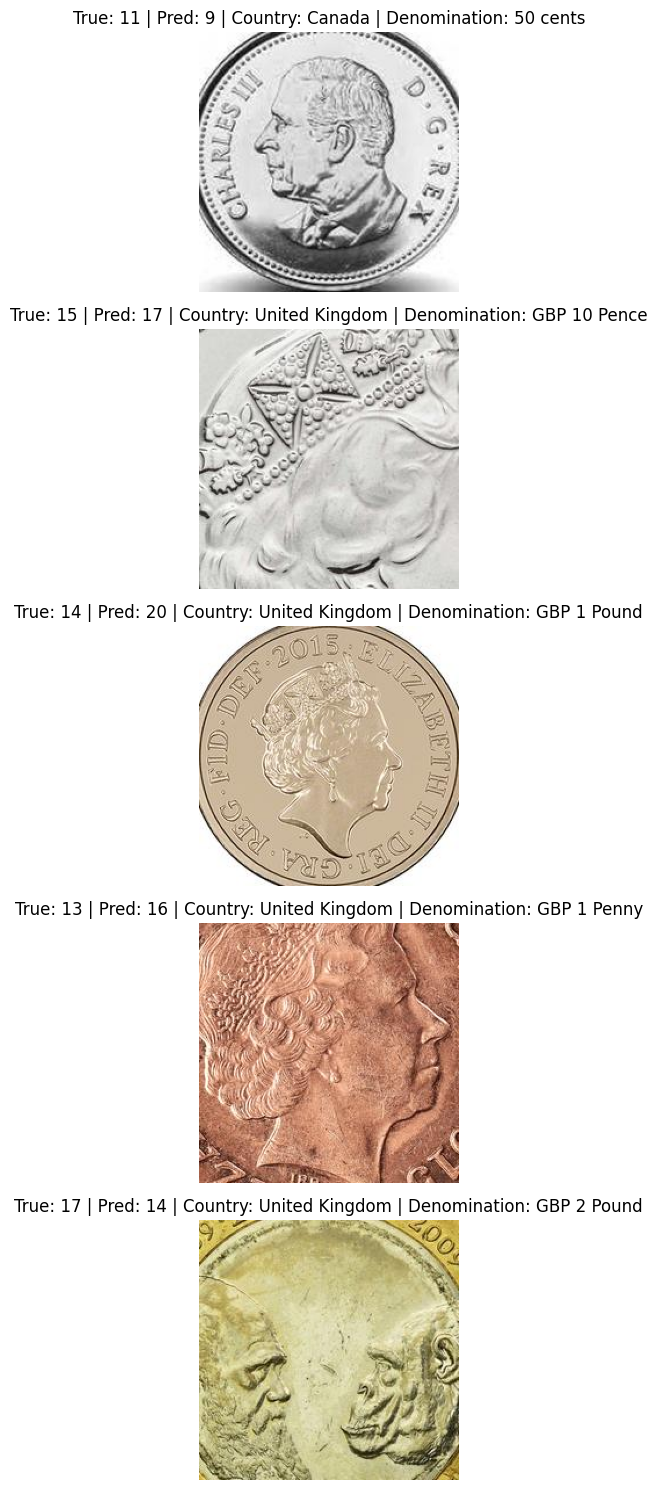

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Display N sample misclassified images
def show_misclassified_images(df, num_samples=5):
    sample_df = df.sample(n=min(num_samples, len(df)), random_state=42)

    plt.figure(figsize=(15, 3 * num_samples))

    for idx, row in enumerate(sample_df.itertuples(), 1):
        img_path = f"{row.URL}/{row._2}"  # _2 because 'image name' is the second column
        image = mpimg.imread(img_path)

        plt.subplot(num_samples, 1, idx)
        plt.imshow(image)
        plt.axis("off")
        plt.title(f"True: {row.true} | Pred: {row.pred} | Country: {row.country} | Denomination: {row.label}")

    plt.tight_layout()
    plt.show()

# Call it
show_misclassified_images(misclassified, num_samples=5)

# **GoogLeNet: Full Fine-tune + ReduceLROnPlateau**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torchvision.models import GoogLeNet_Weights
from tqdm import tqdm
from sklearn.metrics import classification_report

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === GoogLeNet Setup ===
print("\n--- GoogLeNet: Full Fine-tune + ReduceLROnPlateau ---")
googlenet_full = models.googlenet(weights=GoogLeNet_Weights.IMAGENET1K_V1, aux_logits=True)

# Replace final classifier
googlenet_full.fc = nn.Linear(googlenet_full.fc.in_features, num_classes)
googlenet_full = googlenet_full.to(device)

# Optimizer, scheduler, loss
optimizer = optim.Adam(googlenet_full.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)
criterion = nn.CrossEntropyLoss()

# === Training Function ===
def train_model_plateau(model, criterion, optimizer, scheduler, num_epochs=10):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)

        for inputs, labels in loop:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            if hasattr(outputs, 'logits'):
                outputs = outputs.logits

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            loop.set_postfix(loss=loss.item(), acc=correct / total)

        train_loss = running_loss / total
        train_acc = correct / total
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        # === Validation ===
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                if hasattr(outputs, 'logits'):
                    outputs = outputs.logits

                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * inputs.size(0)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        scheduler.step(val_loss)

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
              f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

    return model, history

# === Run Training ===
googlenet_full, history_goog_full = train_model_plateau(
    model=googlenet_full,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=10
)


--- GoogLeNet: Full Fine-tune + ReduceLROnPlateau ---


/usr/local/lib/python3.11/dist-packages/torchvision/models/googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1: Train Loss=1.3961, Train Acc=0.6069, Val Loss=0.5420, Val Acc=0.8585


Epoch 2: Train Loss=0.4202, Train Acc=0.8612, Val Loss=0.7541, Val Acc=0.7925


Epoch 3: Train Loss=0.3167, Train Acc=0.9033, Val Loss=0.6255, Val Acc=0.7925


...

Epoch 6: Train Loss=0.0905, Train Acc=0.9774, Val Loss=0.3418, Val Acc=0.9151


Epoch 7: Train Loss=0.0742, Train Acc=0.9750, Val Loss=0.5627, Val Acc=0.8491


Epoch 8: Train Loss=0.0898, Train Acc=0.9719, Val Loss=0.3857, Val Acc=0.8679


Epoch 9: Train Loss=0.0792, Train Acc=0.9750, Val Loss=0.5148, Val Acc=0.8679


Epoch 10: Train Loss=0.0533, Train Acc=0.9821, Val Loss=0.5405, Val Acc=0.8679


In [ ]:
import pandas as pd

def get_evaluation_df(model, test_loader, class_df):
    model.eval()
    rows = []

    with torch.no_grad():
        for idx, (inputs, labels) in enumerate(test_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            if hasattr(outputs, 'logits'):
                outputs = outputs.logits
            _, preds = torch.max(outputs, 1)

            for i in range(len(labels)):
                row = {
                    'true_label': labels[i].item(),
                    'pred_label': preds[i].item(),
                    'correct': preds[i].item() == labels[i].item()
                }
                rows.append(row)

    result_df = pd.DataFrame(rows)
    result_df = pd.concat([result_df, class_df.reset_index(drop=True)], axis=1)
    return result_df

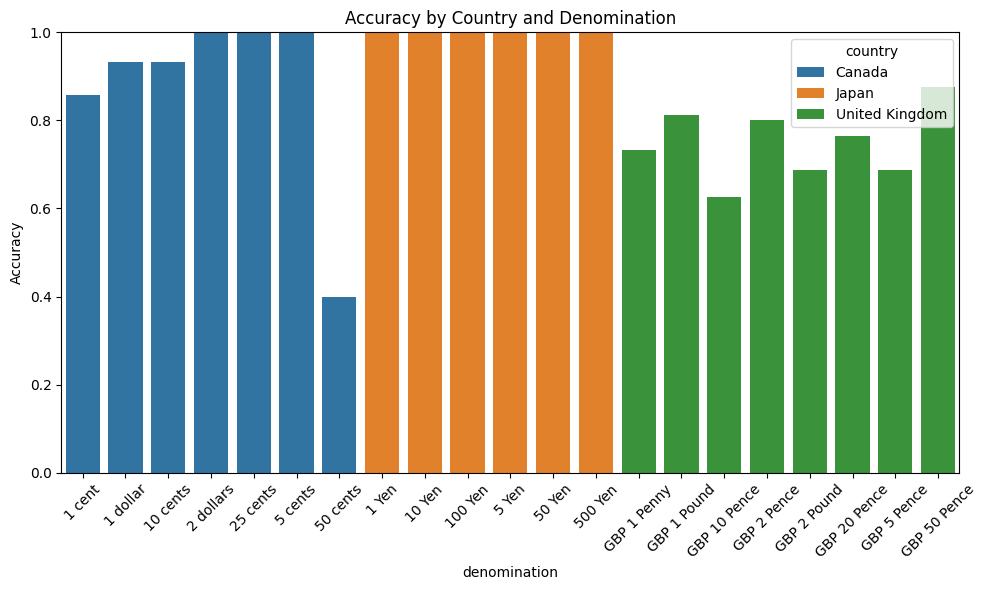

In [ ]:
group_acc = evaluated_df.groupby(['country', 'label'])['correct'].value_counts().unstack().fillna(0)
group_acc['accuracy'] = group_acc[True] / (group_acc[True] + group_acc[False])

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(data=group_acc.reset_index(), x='label', y='accuracy', hue='country')
plt.title("Accuracy by Country and Denomination")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Total misclassified images: 47


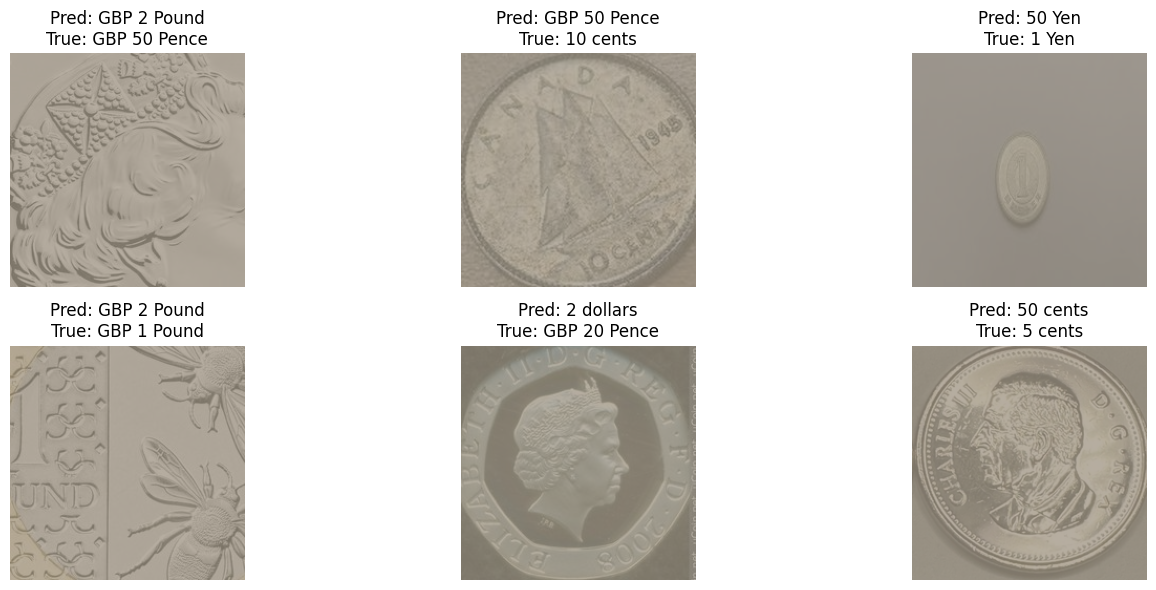

In [ ]:
misclassified = get_misclassified_images(googlenet_full, test_loader)
print(f"Total misclassified images: {len(misclassified)}")
show_misclassified_images(misclassified, class_names, num_samples=6)

# **GoogLeNet: Last 2 Blocks + FC + CosineAnnealingLR**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torchvision.models import GoogLeNet_Weights
from tqdm import tqdm
from sklearn.metrics import classification_report

# ✅ Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === GoogLeNet Setup ===
print("\n--- GoogLeNet: Last 2 Blocks + FC + CosineAnnealingLR ---")
googlenet_partial = models.googlenet(weights=GoogLeNet_Weights.IMAGENET1K_V1, aux_logits=True)

# Replace final classifier
googlenet_partial.fc = nn.Linear(googlenet_partial.fc.in_features, num_classes)

# Freeze all layers first
for param in googlenet_partial.parameters():
    param.requires_grad = False

# Unfreeze last blocks and FC layer
for name, module in googlenet_partial.named_children():
    if name in ["inception4e", "inception5a", "inception5b", "fc"]:
        for param in module.parameters():
            param.requires_grad = True

googlenet_partial = googlenet_partial.to(device)

# Optimizer, scheduler, and loss
trainable_params = filter(lambda p: p.requires_grad, googlenet_partial.parameters())
optimizer = optim.Adam(trainable_params, lr=0.001)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
criterion = nn.CrossEntropyLoss()

# === Training Function ===
def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)

        for inputs, labels in loop:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            if hasattr(outputs, 'logits'):
                outputs = outputs.logits
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            loop.set_postfix(loss=loss.item(), acc=correct / total)

        scheduler.step()
        train_loss = running_loss / total
        train_acc = correct / total
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                if hasattr(outputs, 'logits'):
                    outputs = outputs.logits
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * inputs.size(0)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
              f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

    return model, history

# === Run Training
googlenet_partial, history_partial = train_model(
    model=googlenet_partial,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=10
)


--- GoogLeNet: Last 2 Blocks + FC + CosineAnnealingLR ---


/usr/local/lib/python3.11/dist-packages/torchvision/models/googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(


Epoch 1: Train Loss=1.4594, Train Acc=0.6092, Val Loss=0.6017, Val Acc=0.7925


Epoch 2: Train Loss=0.3178, Train Acc=0.9080, Val Loss=0.4816, Val Acc=0.8491


Epoch 3: Train Loss=0.1864, Train Acc=0.9493, Val Loss=0.4146, Val Acc=0.8396


...

Epoch 6: Train Loss=0.0545, Train Acc=0.9836, Val Loss=0.5184, Val Acc=0.8679


Epoch 7: Train Loss=0.0419, Train Acc=0.9914, Val Loss=0.4673, Val Acc=0.8868


Epoch 8: Train Loss=0.0336, Train Acc=0.9914, Val Loss=0.4365, Val Acc=0.8868


Epoch 9: Train Loss=0.0307, Train Acc=0.9906, Val Loss=0.4208, Val Acc=0.8774


Epoch 10: Train Loss=0.0286, Train Acc=0.9945, Val Loss=0.4232, Val Acc=0.8962


In [ ]:
from sklearn.metrics import classification_report

# === Basic Evaluation Function
def evaluate_model(model, test_loader, class_names):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            if hasattr(outputs, 'logits'):
                outputs = outputs.logits

            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print("\nClassification Report:\n")
    print(classification_report(all_labels, all_preds, target_names=class_names))

# === Misclassified Sample Collector
def get_misclassified_images(model, test_loader):
    model.eval()
    misclassified = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            if hasattr(outputs, 'logits'):
                outputs = outputs.logits

            _, preds = torch.max(outputs, 1)
            misclassified_batch = preds != labels

            for img, pred, true in zip(inputs[misclassified_batch], preds[misclassified_batch], labels[misclassified_batch]):
                misclassified.append((img.cpu(), pred.item(), true.item()))

    return misclassified

# === Example Usage
evaluate_model(googlenet_partial, test_loader, class_names)

misclassified = get_misclassified_images(googlenet_partial, test_loader)
print(f"Total misclassified images: {len(misclassified)}")


Classification Report:

              precision    recall  f1-score   support

       1 Yen       0.93      0.93      0.93        15
      1 cent       0.87      0.93      0.90        14
    1 dollar       0.94      1.00      0.97        15
      10 Yen       1.00      1.00      1.00        15
    10 cents       1.00      0.87      0.93        15
     100 Yen       1.00      1.00      1.00        15
   2 dollars       1.00      1.00      1.00        15
    25 cents       0.76      0.87      0.81        15
       5 Yen       0.94      1.00      0.97        15
     5 cents       0.65      0.94      0.77        16
      50 Yen       0.94      1.00      0.97        15
    50 cents       0.86      0.40      0.55        15
     500 Yen       0.88      1.00      0.94        15
 GBP 1 Penny       0.67      0.80      0.73        15
 GBP 1 Pound       0.80      0.75      0.77        16
GBP 10 Pence       0.90      0.56      0.69        16
 GBP 2 Pence       0.91      0.67      0.77        15
 G

In [ ]:
import pandas as pd

def get_evaluation_dataframe(model, test_loader, test_metadata_df):
    model.eval()
    predictions = []

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(test_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            if hasattr(outputs, 'logits'):
                outputs = outputs.logits

            _, preds = torch.max(outputs, 1)

            for idx in range(inputs.size(0)):
                predictions.append({
                    "true_label": labels[idx].item(),
                    "pred_label": preds[idx].item(),
                    "correct": preds[idx].item() == labels[idx].item()
                })

    # Convert to DataFrame
    pred_df = pd.DataFrame(predictions)

    # Merge with metadata (which must align row-wise with test_loader dataset)
    evaluated_df = pd.concat([test_metadata_df.reset_index(drop=True), pred_df], axis=1)
    return evaluated_df


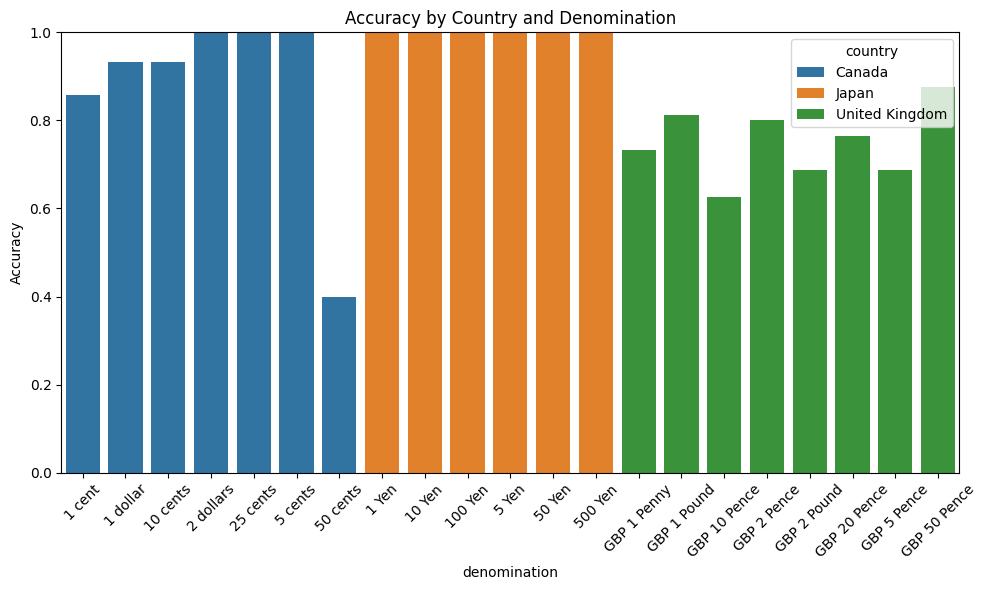

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Group by country + denomination and compute accuracy
group_acc = evaluated_df.groupby(['country', 'label'])['correct'].value_counts().unstack().fillna(0)
group_acc['accuracy'] = group_acc[True] / (group_acc[True] + group_acc[False])

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=group_acc.reset_index(), x='label', y='accuracy', hue='country')
plt.title("Accuracy by Country and Denomination")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import torchvision.transforms.functional as F

def show_misclassified_images(misclassified, class_names, num_samples=6):
    num_samples = min(num_samples, len(misclassified))

    plt.figure(figsize=(15, 6))

    for i in range(num_samples):
        img_tensor, pred_idx, true_idx = misclassified[i]

        # Unnormalize using ImageNet stats
        img = F.normalize(img_tensor,
                          mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
                          std=[1 / 0.229, 1 / 0.224, 1 / 0.225])

        img = img.permute(1, 2, 0).cpu().numpy().clip(0, 1)  # CHW → HWC

        plt.subplot(2, (num_samples + 1) // 2, i + 1)
        plt.imshow(img)
        plt.title(f"Pred: {class_names[pred_idx]}\nTrue: {class_names[true_idx]}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

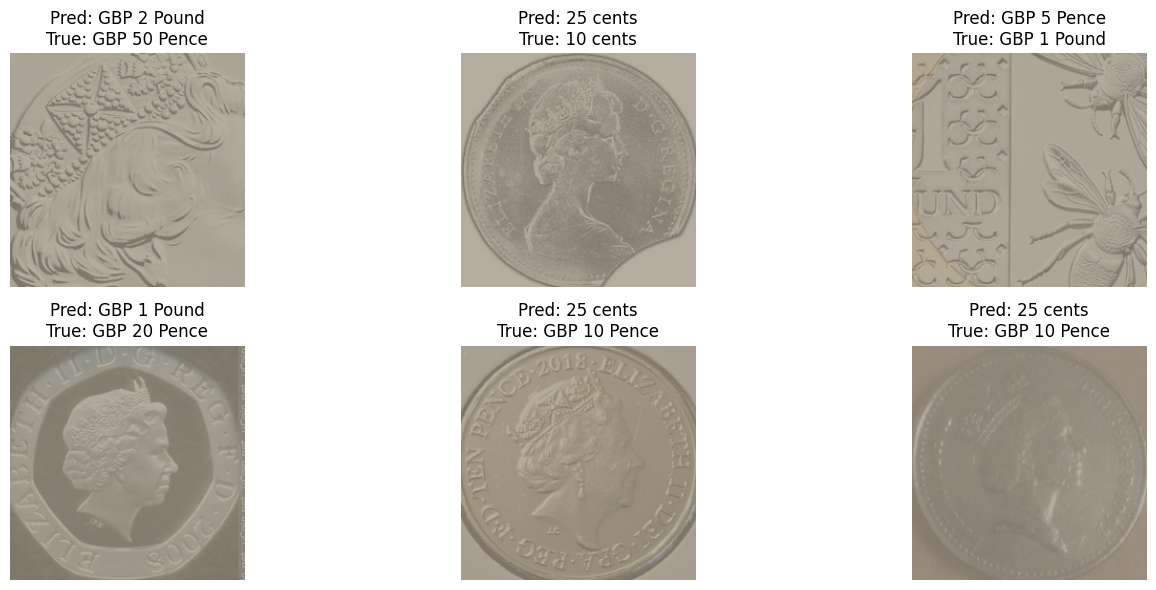

In [ ]:
show_misclassified_images(misclassified, class_names, num_samples=6)

# **ResNet18: Original + Augmented + 2 layer Fine-tune + CosineAnnealingLR**




In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

#  Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#  Transforms
original_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

augmented_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

#  Dataset class
class CoinImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = row['URL'] + '/' + str(row['image name']).strip()
        image = Image.open(image_path).convert("RGB")
        label = row['encoded_class']
        if self.transform:
            image = self.transform(image)
        return image, label

#  Label encoding
label_encoder = LabelEncoder()
japan_canada_uk_train_df['encoded_class'] = label_encoder.fit_transform(japan_canada_uk_train_df['label'].str.strip())
japan_canada_uk_val_df['encoded_class'] = label_encoder.transform(japan_canada_uk_val_df['label'].str.strip())
japan_canada_uk_test_df['encoded_class'] = label_encoder.transform(japan_canada_uk_test_df['label'].str.strip())

class_names = label_encoder.classes_
num_classes = len(class_names)

#  Datasets and Dataloaders
train_dataset_original = CoinImageDataset(japan_canada_uk_train_df, transform=original_transform)
train_dataset_augmented = CoinImageDataset(japan_canada_uk_train_df, transform=augmented_transform)
combined_train_dataset = ConcatDataset([train_dataset_original, train_dataset_augmented])

train_loader = DataLoader(combined_train_dataset, batch_size=32, shuffle=True, drop_last=True)
val_loader = DataLoader(CoinImageDataset(japan_canada_uk_val_df, transform=original_transform), batch_size=32)
test_loader = DataLoader(CoinImageDataset(japan_canada_uk_test_df, transform=original_transform), batch_size=32)

#  Model: ResNet18 last 2 blocks + fc
print("\n--- ResNet18: Original + Augmented + Fine-tune + CosineAnnealingLR ---")
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
resnet.fc = nn.Linear(resnet.fc.in_features, num_classes)

for param in resnet.parameters():
    param.requires_grad = False

for name, param in resnet.named_parameters():
    if "layer3" in name or "layer4" in name or "fc" in name:
        param.requires_grad = True

resnet = resnet.to(device)

#  Optimizer, Scheduler, Criterion
trainable_params = filter(lambda p: p.requires_grad, resnet.parameters())
optimizer = optim.Adam(trainable_params, lr=0.001)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
criterion = nn.CrossEntropyLoss()

#  Training loop
def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)

        for inputs, labels in loop:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            loop.set_postfix(loss=loss.item(), acc=correct / total)

        scheduler.step()
        train_loss = running_loss / total
        train_acc = correct / total
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        #  Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * inputs.size(0)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
              f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

    return model, history

#  Train
resnet, history_combined = train_model(resnet, criterion, optimizer, scheduler, num_epochs=10)


--- ResNet18: Original + Augmented + Fine-tune + CosineAnnealingLR ---


Epoch 1: Train Loss=1.1047, Train Acc=0.6758, Val Loss=0.6046, Val Acc=0.8113


Epoch 2: Train Loss=0.2930, Train Acc=0.9109, Val Loss=0.7567, Val Acc=0.7925


Epoch 3: Train Loss=0.2145, Train Acc=0.9328, Val Loss=0.5483, Val Acc=0.8679


Epoch 4: Train Loss=0.1309, Train Acc=0.9578, Val Loss=0.4346, Val Acc=0.8585


...

Epoch 6: Train Loss=0.0646, Train Acc=0.9773, Val Loss=0.7532, Val Acc=0.8491


Epoch 7: Train Loss=0.0468, Train Acc=0.9852, Val Loss=0.4282, Val Acc=0.8491


Epoch 8: Train Loss=0.0334, Train Acc=0.9898, Val Loss=0.5115, Val Acc=0.8679


Epoch 9: Train Loss=0.0241, Train Acc=0.9906, Val Loss=0.4976, Val Acc=0.8679


Epoch 10: Train Loss=0.0209, Train Acc=0.9961, Val Loss=0.4973, Val Acc=0.8679

Classification Report:

              precision    recall  f1-score   support

       1 Yen       1.00      0.87      0.93        15
      1 cent       1.00      0.93      0.96        14
    1 dollar       1.00      1.00      1.00        15
      10 Yen       1.00      1.00      1.00        15
    10 cents       0.94      1.00      0.97        15
     100 Yen       0.94      1.00      0.97        15
   2 dollars       0.94      1.00      0.97        15
    25 cents       1.00      1.00      1.00        15
       5 Yen       1.00      1.00      1.00        15
     5 cents       0.75      0.94      0.83        16
      50 Yen       1.00      1.00      1.00        15
    50 cents       0.83      0.67      0.74        15
     500 Yen       1.00      1.00      1.00        15
 GBP 1 Penny       0.71      0.80      0.75        15
 GBP 1 Pound       0.88      0.88      0.88        16
GBP 10 Pence       0.83      0.

In [ ]:
from sklearn.metrics import classification_report

def evaluate_model(model, test_loader, class_names):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print("\nClassification Report:\n")
    print(classification_report(all_labels, all_preds, target_names=class_names))

In [ ]:
def get_misclassified_images(model, test_loader):
    model.eval()
    misclassified = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            misclassified_batch = preds != labels
            for img, pred, true in zip(inputs[misclassified_batch], preds[misclassified_batch], labels[misclassified_batch]):
                misclassified.append((img.cpu(), pred.item(), true.item()))

    return misclassified

In [ ]:
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F

def show_misclassified_images(misclassified, class_names, num_samples=6):
    num_samples = min(num_samples, len(misclassified))
    plt.figure(figsize=(15, 6))

    for i in range(num_samples):
        img_tensor, pred_idx, true_idx = misclassified[i]

        # Unnormalize using ImageNet stats
        img = F.normalize(img_tensor,
                          mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
                          std=[1 / 0.229, 1 / 0.224, 1 / 0.225])

        img = img.permute(1, 2, 0).numpy().clip(0, 1)

        plt.subplot(2, (num_samples + 1) // 2, i + 1)
        plt.imshow(img)
        plt.title(f"Pred: {class_names[pred_idx]}\nTrue: {class_names[true_idx]}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()


Classification Report:

              precision    recall  f1-score   support

       1 Yen       0.59      0.87      0.70        15
      1 cent       1.00      0.36      0.53        14
    1 dollar       0.87      0.87      0.87        15
      10 Yen       1.00      1.00      1.00        15
    10 cents       0.79      1.00      0.88        15
     100 Yen       0.79      1.00      0.88        15
   2 dollars       0.88      1.00      0.94        15
    25 cents       0.82      0.93      0.88        15
       5 Yen       1.00      1.00      1.00        15
     5 cents       0.68      0.94      0.79        16
      50 Yen       1.00      1.00      1.00        15
    50 cents       0.89      0.53      0.67        15
     500 Yen       1.00      0.87      0.93        15
 GBP 1 Penny       0.90      0.60      0.72        15
 GBP 1 Pound       0.59      0.81      0.68        16
GBP 10 Pence       0.60      0.38      0.46        16
 GBP 2 Pence       1.00      0.53      0.70        15
 G

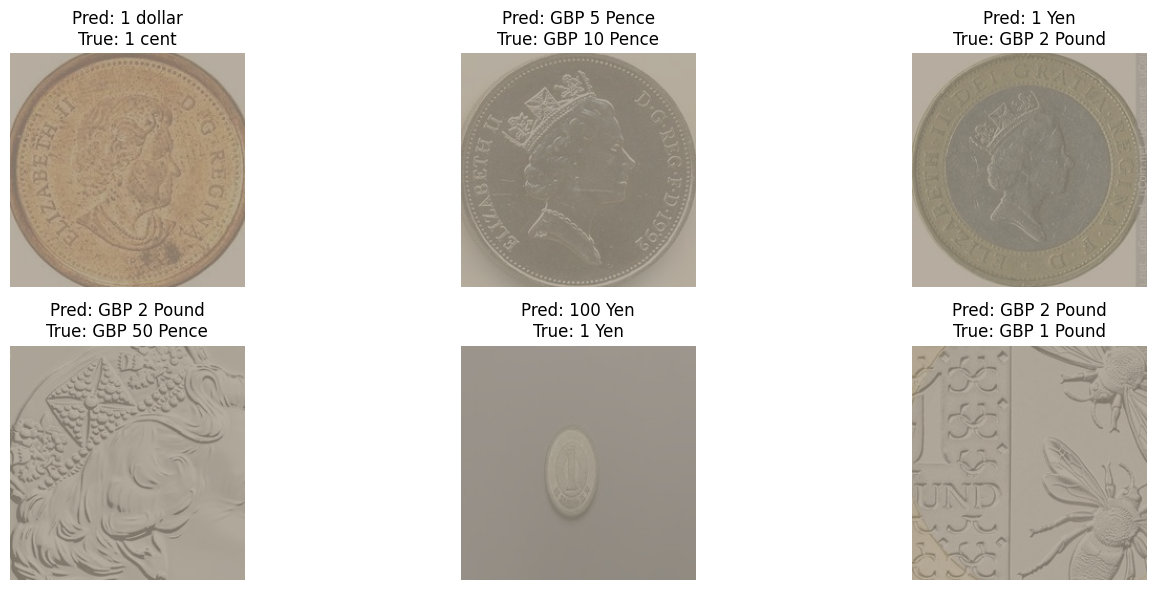

In [ ]:
# Evaluate normally
evaluate_model(resnet, test_loader, class_names)

# Collect misclassified images
misclassified = get_misclassified_images(resnet, test_loader)
print(f"Total misclassified images: {len(misclassified)}")

# Show a few
show_misclassified_images(misclassified, class_names, num_samples=6)

In [ ]:
import pandas as pd

def get_evaluation_dataframe(model, test_loader, original_df):
    model.eval()
    results = []

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(test_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size(0)):
                results.append({
                    "true_label": labels[j].item(),
                    "pred_label": preds[j].item(),
                    "correct": preds[j].item() == labels[j].item()
                })

    pred_df = pd.DataFrame(results)

    # Combine with original test metadata (ensure aligned order)
    metadata = japan_canada_uk_test_df.reset_index(drop=True)[['country', 'label']]
    evaluated_df = pd.concat([metadata, pred_df], axis=1)
    return evaluated_df

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_group_accuracy(evaluated_df):
    group_acc = evaluated_df.groupby(['country', 'label'])['correct'].value_counts().unstack().fillna(0)
    group_acc['accuracy'] = group_acc[True] / (group_acc[True] + group_acc[False])

    plt.figure(figsize=(10, 6))
    sns.barplot(data=group_acc.reset_index(), x='label', y='accuracy', hue='country')
    plt.title("Accuracy by Country and Denomination")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

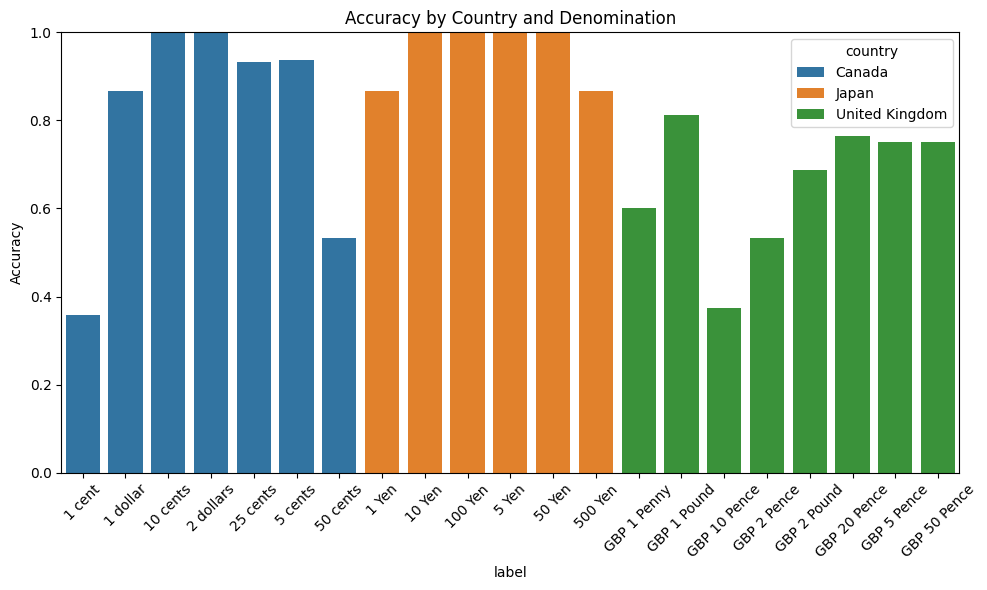

In [ ]:
evaluated_df = get_evaluation_dataframe(resnet, test_loader, japan_canada_uk_test_df)
plot_group_accuracy(evaluated_df)

# **ResNet18: Full Fine-tune + ReduceLROnPlateau + Augmented+Original Images**



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import ConcatDataset, DataLoader, Dataset
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import classification_report
from torchvision.models import ResNet18_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Transforms (Original + Augmented) ===
original_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

augmented_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# === Dataset Class ===
class CoinImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = row['URL'] + '/' + str(row['image name']).strip()
        image = Image.open(image_path).convert("RGB")
        label = row['encoded_class']
        if self.transform:
            image = self.transform(image)
        return image, label

# === Datasets & Dataloaders ===
train_dataset_original = CoinImageDataset(japan_canada_uk_train_df, transform=original_transform)
train_dataset_augmented = CoinImageDataset(japan_canada_uk_train_df, transform=augmented_transform)
combined_train_dataset = ConcatDataset([train_dataset_original, train_dataset_augmented])

train_loader = DataLoader(combined_train_dataset, batch_size=32, shuffle=True, drop_last=True)
val_loader = DataLoader(CoinImageDataset(japan_canada_uk_val_df, transform=original_transform), batch_size=32)
test_loader = DataLoader(CoinImageDataset(japan_canada_uk_test_df, transform=original_transform), batch_size=32)

# === Model Setup: ResNet18 ===
print("\n--- ResNet18: Fine-tune + ReduceLROnPlateau + Augmented+Original Images ---")
resnet = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
resnet.fc = nn.Linear(resnet.fc.in_features, num_classes)
resnet = resnet.to(device)

# All layers trainable (Full Fine-tune)
optimizer = optim.Adam(resnet.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)
criterion = nn.CrossEntropyLoss()

# === Training Function ===
def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)

        for inputs, labels in loop:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            loop.set_postfix(loss=loss.item(), acc=correct / total)

        scheduler.step(running_loss / total)
        train_loss = running_loss / total
        train_acc = correct / total
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        # === Validation ===
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * inputs.size(0)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
              f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

    return model, history

# === Train Model ===
resnet, history = train_model(resnet, criterion, optimizer, scheduler, num_epochs=10)

# === Evaluation ===
def evaluate_model(model, test_loader, class_names):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print("\nClassification Report:\n")
    print(classification_report(all_labels, all_preds, target_names=class_names))

evaluate_model(resnet, test_loader, class_names)


--- ResNet18: Full Fine-tune + ReduceLROnPlateau + Augmented+Original Images ---


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1: Train Loss=1.3477, Train Acc=0.5998, Val Loss=1.1238, Val Acc=0.6604


Epoch 2: Train Loss=0.5642, Train Acc=0.8222, Val Loss=0.9882, Val Acc=0.7170


Epoch 3: Train Loss=0.4160, Train Acc=0.8768, Val Loss=0.7287, Val Acc=0.7736


...

Epoch 6: Train Loss=0.2248, Train Acc=0.9228, Val Loss=0.8363, Val Acc=0.7925


Epoch 7: Train Loss=0.1210, Train Acc=0.9680, Val Loss=0.5858, Val Acc=0.8585


Epoch 8: Train Loss=0.1152, Train Acc=0.9610, Val Loss=0.6758, Val Acc=0.8396


Epoch 9: Train Loss=0.0827, Train Acc=0.9704, Val Loss=0.4991, Val Acc=0.8868


Epoch 10: Train Loss=0.0775, Train Acc=0.9719, Val Loss=0.5578, Val Acc=0.8774

Classification Report:

              precision    recall  f1-score   support

       1 Yen       0.93      0.87      0.90        15
      1 cent       1.00      0.86      0.92        14
    1 dollar       0.88      1.00      0.94        15
      10 Yen       1.00      1.00      1.00        15
    10 cents       1.00      0.93      0.97        15
     100 Yen       1.00      1.00      1.00        15
   2 dollars       1.00      1.00      1.00        15
    25 cents       1.00      0.87      0.93        15
       5 Yen       0.94      1.00      0.97        15
     5 cents       0.75      0.75      0.75        16
      50 Yen       0.83      1.00      0.91        15
    50 cents       0.69      0.73      0.71        15
     500 Yen       1.00      1.00      1.00        15
 GBP 1 Penny       0.79      0.73      0.76        15
 GBP 1 Pound       0.76      0.81      0.79        16
GBP 10 Pence       0.71      0.

In [ ]:
def get_misclassified_images(model, test_loader):
    model.eval()
    misclassified = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            misclassified_batch = preds != labels
            for img, pred, true in zip(inputs[misclassified_batch], preds[misclassified_batch], labels[misclassified_batch]):
                misclassified.append((img.cpu(), pred.item(), true.item()))

    return misclassified

In [ ]:
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F

def show_misclassified_images(misclassified, class_names, num_samples=6):
    num_samples = min(num_samples, len(misclassified))
    plt.figure(figsize=(15, 6))

    for i in range(num_samples):
        img_tensor, pred_idx, true_idx = misclassified[i]

        # Unnormalize (ImageNet stats)
        img = F.normalize(img_tensor,
                          mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
                          std=[1 / 0.229, 1 / 0.224, 1 / 0.225])
        img = img.permute(1, 2, 0).numpy().clip(0, 1)

        plt.subplot(2, (num_samples + 1) // 2, i + 1)
        plt.imshow(img)
        plt.title(f"Pred: {class_names[pred_idx]}\nTrue: {class_names[true_idx]}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()


Classification Report:

              precision    recall  f1-score   support

       1 Yen       0.59      0.87      0.70        15
      1 cent       1.00      0.36      0.53        14
    1 dollar       0.87      0.87      0.87        15
      10 Yen       1.00      1.00      1.00        15
    10 cents       0.79      1.00      0.88        15
     100 Yen       0.79      1.00      0.88        15
   2 dollars       0.88      1.00      0.94        15
    25 cents       0.82      0.93      0.88        15
       5 Yen       1.00      1.00      1.00        15
     5 cents       0.68      0.94      0.79        16
      50 Yen       1.00      1.00      1.00        15
    50 cents       0.89      0.53      0.67        15
     500 Yen       1.00      0.87      0.93        15
 GBP 1 Penny       0.90      0.60      0.72        15
 GBP 1 Pound       0.59      0.81      0.68        16
GBP 10 Pence       0.60      0.38      0.46        16
 GBP 2 Pence       1.00      0.53      0.70        15
 G

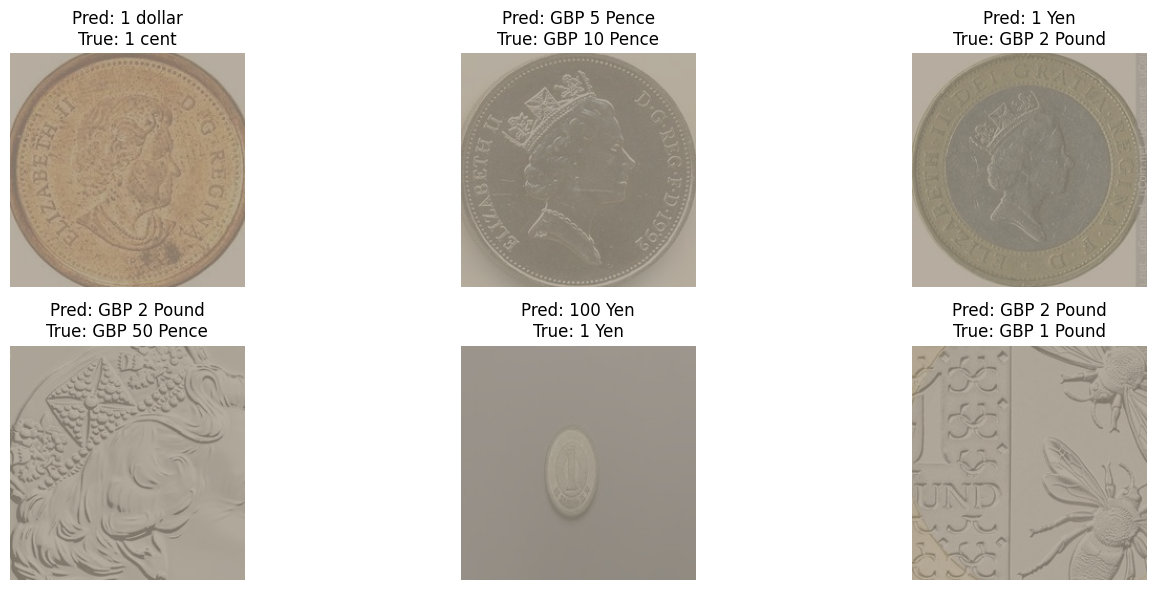

In [ ]:
# Evaluate performance
evaluate_model(resnet, test_loader, class_names)

# Collect and display misclassified examples
misclassified = get_misclassified_images(resnet, test_loader)
print(f"Total misclassified images: {len(misclassified)}")

# Show a few misclassified samples
show_misclassified_images(misclassified, class_names, num_samples=6)

In [ ]:
def get_evaluated_df(model, test_loader, original_df):
    model.eval()
    results = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for i in range(len(labels)):
                results.append({
                    "true_label": labels[i].item(),
                    "pred_label": preds[i].item(),
                    "correct": preds[i].item() == labels[i].item()
                })

    pred_df = pd.DataFrame(results)

    # Make sure your original_df has 'country' and 'label' columns
    meta_cols = ['country', 'label']
    evaluated_df = pd.concat([original_df.reset_index(drop=True)[meta_cols], pred_df], axis=1)

    return evaluated_df

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_grouped_accuracy(evaluated_df):
    group_acc = evaluated_df.groupby(['country', 'label'])['correct'].value_counts().unstack().fillna(0)
    group_acc['accuracy'] = group_acc[True] / (group_acc[True] + group_acc[False])

    plt.figure(figsize=(10, 6))
    sns.barplot(data=group_acc.reset_index(), x='label', y='accuracy', hue='country')
    plt.title("Accuracy by Country and Label")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

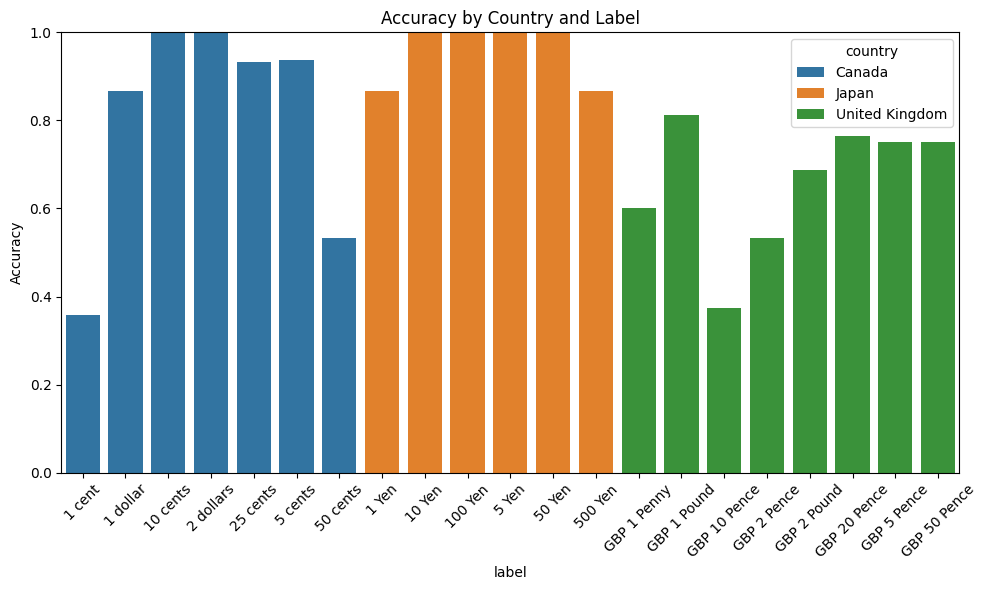

In [ ]:
evaluated_df = get_evaluated_df(resnet, test_loader, japan_canada_uk_test_df)
plot_grouped_accuracy(evaluated_df)

# **GoogLeNet: Full Fine-tune + ReduceLROnPlateau + Augmented + Original Images**


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torchvision.models import GoogLeNet_Weights

# === Model Setup: GoogLeNet ===
print("\n--- GoogLeNet: Full Fine-tune + ReduceLROnPlateau + Augmented+Original Images ---")
googlenet = models.googlenet(weights=GoogLeNet_Weights.IMAGENET1K_V1, aux_logits=True)
googlenet.fc = nn.Linear(googlenet.fc.in_features, num_classes)
googlenet = googlenet.to(device)

# Full fine-tune: all layers trainable
optimizer = optim.Adam(googlenet.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)
criterion = nn.CrossEntropyLoss()

# === Training Function ===
def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)

        for inputs, labels in loop:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            if hasattr(outputs, 'logits'):
                outputs = outputs.logits  # GoogLeNet has .logits wrapper
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            loop.set_postfix(loss=loss.item(), acc=correct / total)

        scheduler.step(running_loss / total)
        train_loss = running_loss / total
        train_acc = correct / total
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        # === Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                if hasattr(outputs, 'logits'):
                    outputs = outputs.logits
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * inputs.size(0)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
              f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

    return model, history

# === Train
googlenet, googlenet_history = train_model(googlenet, criterion, optimizer, scheduler, num_epochs=10)


--- GoogLeNet: Full Fine-tune + ReduceLROnPlateau + Augmented+Original Images ---


/usr/local/lib/python3.11/dist-packages/torchvision/models/googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1: Train Loss=1.3548, Train Acc=0.6201, Val Loss=0.7175, Val Acc=0.7547


Epoch 2: Train Loss=0.4077, Train Acc=0.8783, Val Loss=0.9061, Val Acc=0.7453


Epoch 3: Train Loss=0.3626, Train Acc=0.8955, Val Loss=0.7208, Val Acc=0.7358


...

Epoch 6: Train Loss=0.2364, Train Acc=0.9197, Val Loss=1.0304, Val Acc=0.7547


Epoch 7: Train Loss=0.2765, Train Acc=0.9111, Val Loss=0.6417, Val Acc=0.8113


Epoch 8: Train Loss=0.1697, Train Acc=0.9454, Val Loss=0.7910, Val Acc=0.8019


Epoch 9: Train Loss=0.2152, Train Acc=0.9360, Val Loss=0.5847, Val Acc=0.8585


Epoch 10: Train Loss=0.1768, Train Acc=0.9423, Val Loss=0.6080, Val Acc=0.8113


In [ ]:
from sklearn.metrics import classification_report

def evaluate_model(model, test_loader, class_names):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            if hasattr(outputs, 'logits'):
                outputs = outputs.logits
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print("\nClassification Report:\n")
    print(classification_report(all_labels, all_preds, target_names=class_names))

In [ ]:
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F

def get_misclassified_images(model, test_loader):
    model.eval()
    misclassified = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            if hasattr(outputs, 'logits'):
                outputs = outputs.logits
            _, preds = torch.max(outputs, 1)

            misclassified_batch = preds != labels
            for img, pred, true in zip(inputs[misclassified_batch], preds[misclassified_batch], labels[misclassified_batch]):
                misclassified.append((img.cpu(), pred.item(), true.item()))

    return misclassified

def show_misclassified_images(misclassified, class_names, num_samples=6):
    num_samples = min(num_samples, len(misclassified))
    plt.figure(figsize=(15, 6))

    for i in range(num_samples):
        img_tensor, pred_idx, true_idx = misclassified[i]
        img = F.normalize(img_tensor,
                          mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
                          std=[1 / 0.229, 1 / 0.224, 1 / 0.225])
        img = img.permute(1, 2, 0).numpy().clip(0, 1)

        plt.subplot(2, (num_samples + 1) // 2, i + 1)
        plt.imshow(img)
        plt.title(f"Pred: {class_names[pred_idx]}\nTrue: {class_names[true_idx]}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd
import seaborn as sns

def get_evaluated_df(model, test_loader, original_df):
    model.eval()
    results = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            if hasattr(outputs, 'logits'):
                outputs = outputs.logits
            _, preds = torch.max(outputs, 1)

            for i in range(len(labels)):
                results.append({
                    "true_label": labels[i].item(),
                    "pred_label": preds[i].item(),
                    "correct": preds[i].item() == labels[i].item()
                })

    meta_cols = ['country', 'label']
    pred_df = pd.DataFrame(results)
    evaluated_df = pd.concat([original_df.reset_index(drop=True)[meta_cols], pred_df], axis=1)

    return evaluated_df

def plot_grouped_accuracy(evaluated_df):
    group_acc = evaluated_df.groupby(['country', 'label'])['correct'].value_counts().unstack().fillna(0)
    group_acc['accuracy'] = group_acc[True] / (group_acc[True] + group_acc[False])

    plt.figure(figsize=(10, 6))
    sns.barplot(data=group_acc.reset_index(), x='label', y='accuracy', hue='country')
    plt.title("Accuracy by Country and Label")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


Classification Report:

              precision    recall  f1-score   support

       1 Yen       0.93      0.87      0.90        15
      1 cent       1.00      0.86      0.92        14
    1 dollar       1.00      0.87      0.93        15
      10 Yen       1.00      1.00      1.00        15
    10 cents       1.00      0.87      0.93        15
     100 Yen       1.00      1.00      1.00        15
   2 dollars       0.94      1.00      0.97        15
    25 cents       0.83      1.00      0.91        15
       5 Yen       1.00      1.00      1.00        15
     5 cents       0.78      0.88      0.82        16
      50 Yen       0.88      1.00      0.94        15
    50 cents       0.83      0.67      0.74        15
     500 Yen       1.00      1.00      1.00        15
 GBP 1 Penny       0.83      0.67      0.74        15
 GBP 1 Pound       0.61      0.88      0.72        16
GBP 10 Pence       0.77      0.62      0.69        16
 GBP 2 Pence       0.87      0.87      0.87        15
 G

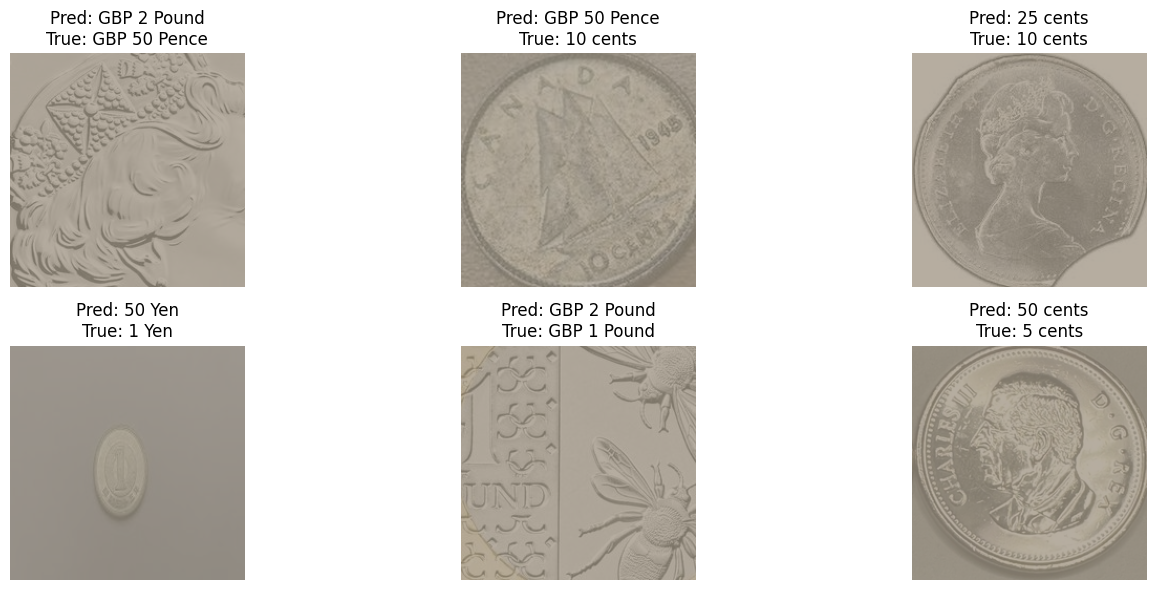

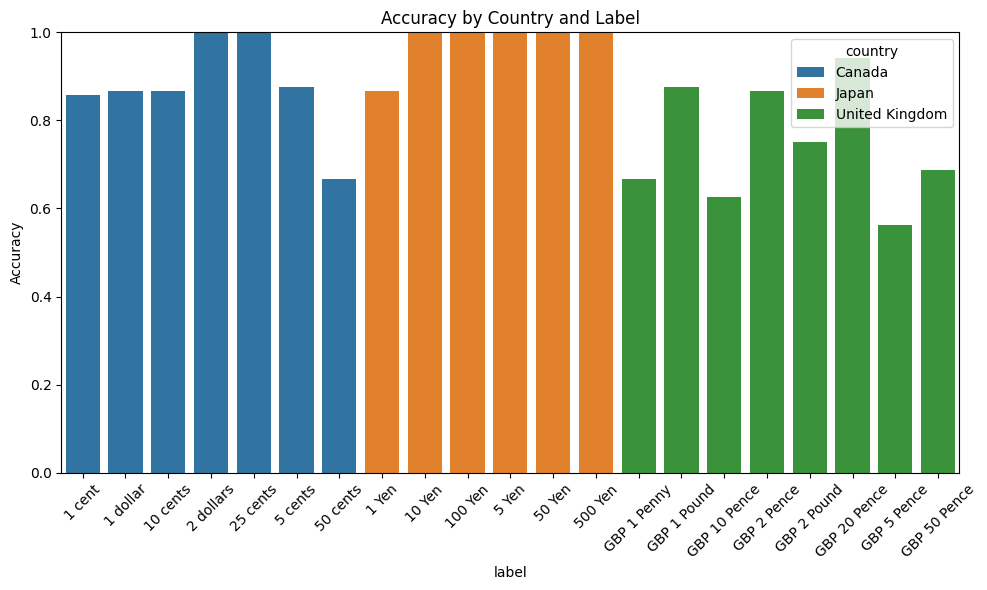

In [ ]:
evaluate_model(googlenet, test_loader, class_names)

misclassified = get_misclassified_images(googlenet, test_loader)
print(f"Total misclassified samples: {len(misclassified)}")
show_misclassified_images(misclassified, class_names, num_samples=6)

evaluated_df = get_evaluated_df(googlenet, test_loader, japan_canada_uk_test_df)
plot_grouped_accuracy(evaluated_df)

# **GoogLeNet: Original + Augmented + 2 layer Fine-tune + CosineAnnealingLR**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torchvision.models import GoogLeNet_Weights
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# === Model Setup: GoogLeNet (partial fine-tune) ===
print("\n--- GoogLeNet: Last 2 Blocks + FC + CosineAnnealingLR ---")
googlenet = models.googlenet(weights=GoogLeNet_Weights.IMAGENET1K_V1, aux_logits=True)
googlenet.fc = nn.Linear(googlenet.fc.in_features, num_classes)

# Freeze all layers first
for param in googlenet.parameters():
    param.requires_grad = False

# Unfreeze inception4e, inception5a, inception5b, and fc
for name, module in googlenet.named_children():
    if name in ["inception4e", "inception5a", "inception5b", "fc"]:
        for param in module.parameters():
            param.requires_grad = True

googlenet = googlenet.to(device)

# Optimizer and Scheduler (only trainable params)
trainable_params = filter(lambda p: p.requires_grad, googlenet.parameters())
optimizer = optim.Adam(trainable_params, lr=0.001)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
criterion = nn.CrossEntropyLoss()

# === Training Function ===
def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)

        for inputs, labels in loop:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            if hasattr(outputs, 'logits'):
                outputs = outputs.logits
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            loop.set_postfix(loss=loss.item(), acc=correct / total)

        scheduler.step()
        train_loss = running_loss / total
        train_acc = correct / total
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        # === Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                if hasattr(outputs, 'logits'):
                    outputs = outputs.logits
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * inputs.size(0)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
              f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

    return model, history

# === Train Model
googlenet, googlenet_history_partial = train_model(googlenet, criterion, optimizer, scheduler, num_epochs=10)


--- GoogLeNet: Last 2 Blocks + FC + CosineAnnealingLR ---


Epoch 1: Train Loss=1.9633, Train Acc=0.4867, Val Loss=0.8249, Val Acc=0.7642


Epoch 2: Train Loss=0.4852, Train Acc=0.8939, Val Loss=0.5089, Val Acc=0.8868


Epoch 3: Train Loss=0.1684, Train Acc=0.9688, Val Loss=0.4987, Val Acc=0.8491


Epoch 4: Train Loss=0.0780, Train Acc=0.9891, Val Loss=0.4127, Val Acc=0.9151


...

Epoch 6: Train Loss=0.0562, Train Acc=0.9938, Val Loss=0.3743, Val Acc=0.8774


Epoch 7: Train Loss=0.0314, Train Acc=0.9938, Val Loss=0.3564, Val Acc=0.8868


Epoch 8: Train Loss=0.0249, Train Acc=0.9938, Val Loss=0.3714, Val Acc=0.8962


Epoch 9: Train Loss=0.0230, Train Acc=0.9953, Val Loss=0.3649, Val Acc=0.8962


Epoch 10: Train Loss=0.0234, Train Acc=0.9969, Val Loss=0.3804, Val Acc=0.8962


In [ ]:
from sklearn.metrics import classification_report

def evaluate_model(model, test_loader, class_names):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            if hasattr(outputs, 'logits'):
                outputs = outputs.logits
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print("\nClassification Report:\n")
    print(classification_report(all_labels, all_preds, target_names=class_names))

In [ ]:
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F

def get_misclassified_images(model, test_loader):
    model.eval()
    misclassified = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            if hasattr(outputs, 'logits'):
                outputs = outputs.logits
            _, preds = torch.max(outputs, 1)

            misclassified_batch = preds != labels
            for img, pred, true in zip(inputs[misclassified_batch], preds[misclassified_batch], labels[misclassified_batch]):
                misclassified.append((img.cpu(), pred.item(), true.item()))

    return misclassified

def show_misclassified_images(misclassified, class_names, num_samples=6):
    num_samples = min(num_samples, len(misclassified))
    plt.figure(figsize=(15, 6))

    for i in range(num_samples):
        img_tensor, pred_idx, true_idx = misclassified[i]
        img = F.normalize(img_tensor,
                          mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
                          std=[1 / 0.229, 1 / 0.224, 1 / 0.225])
        img = img.permute(1, 2, 0).numpy().clip(0, 1)

        plt.subplot(2, (num_samples + 1) // 2, i + 1)
        plt.imshow(img)
        plt.title(f"Pred: {class_names[pred_idx]}\nTrue: {class_names[true_idx]}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd
import seaborn as sns

def get_evaluated_df(model, test_loader, original_df):
    model.eval()
    results = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            if hasattr(outputs, 'logits'):
                outputs = outputs.logits
            _, preds = torch.max(outputs, 1)

            for i in range(len(labels)):
                results.append({
                    "true_label": labels[i].item(),
                    "pred_label": preds[i].item(),
                    "correct": preds[i].item() == labels[i].item()
                })

    meta_cols = ['country', 'label']
    pred_df = pd.DataFrame(results)
    evaluated_df = pd.concat([original_df.reset_index(drop=True)[meta_cols], pred_df], axis=1)

    return evaluated_df

def plot_grouped_accuracy(evaluated_df):
    group_acc = evaluated_df.groupby(['country', 'label'])['correct'].value_counts().unstack().fillna(0)
    group_acc['accuracy'] = group_acc[True] / (group_acc[True] + group_acc[False])

    plt.figure(figsize=(10, 6))
    sns.barplot(data=group_acc.reset_index(), x='label', y='accuracy', hue='country')
    plt.title("Accuracy by Country and Label")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


Classification Report:

              precision    recall  f1-score   support

       1 Yen       0.93      0.93      0.93        15
      1 cent       0.92      0.79      0.85        14
    1 dollar       0.81      0.87      0.84        15
      10 Yen       1.00      1.00      1.00        15
    10 cents       1.00      0.93      0.97        15
     100 Yen       1.00      1.00      1.00        15
   2 dollars       1.00      1.00      1.00        15
    25 cents       0.78      0.93      0.85        15
       5 Yen       0.94      1.00      0.97        15
     5 cents       0.74      0.88      0.80        16
      50 Yen       1.00      1.00      1.00        15
    50 cents       0.77      0.67      0.71        15
     500 Yen       0.83      1.00      0.91        15
 GBP 1 Penny       0.85      0.73      0.79        15
 GBP 1 Pound       0.93      0.81      0.87        16
GBP 10 Pence       0.91      0.62      0.74        16
 GBP 2 Pence       0.80      0.80      0.80        15
 G

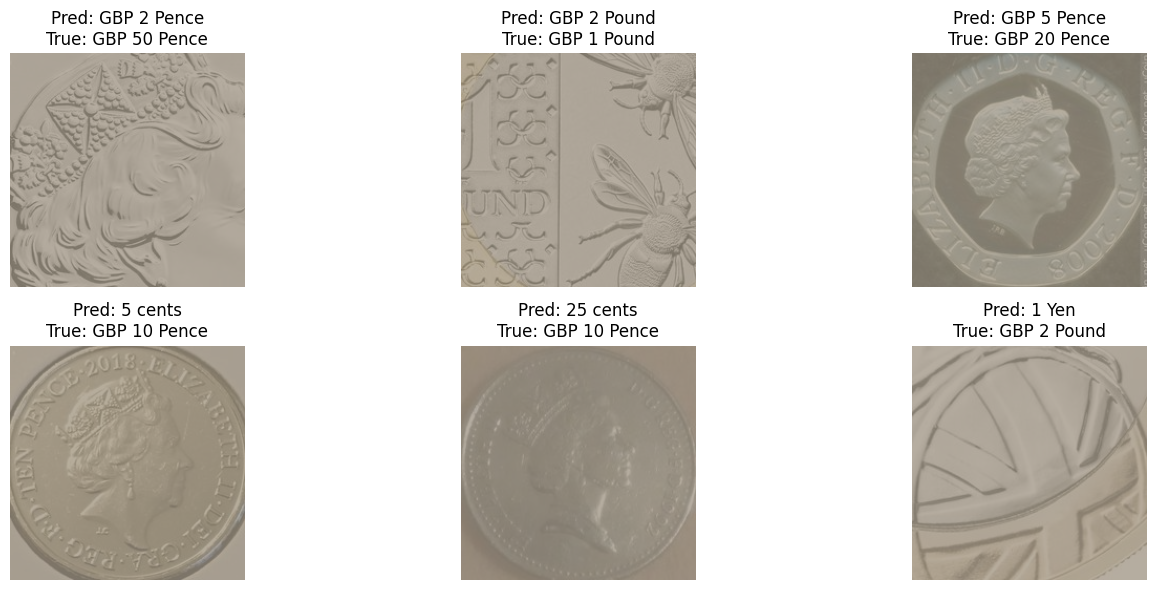

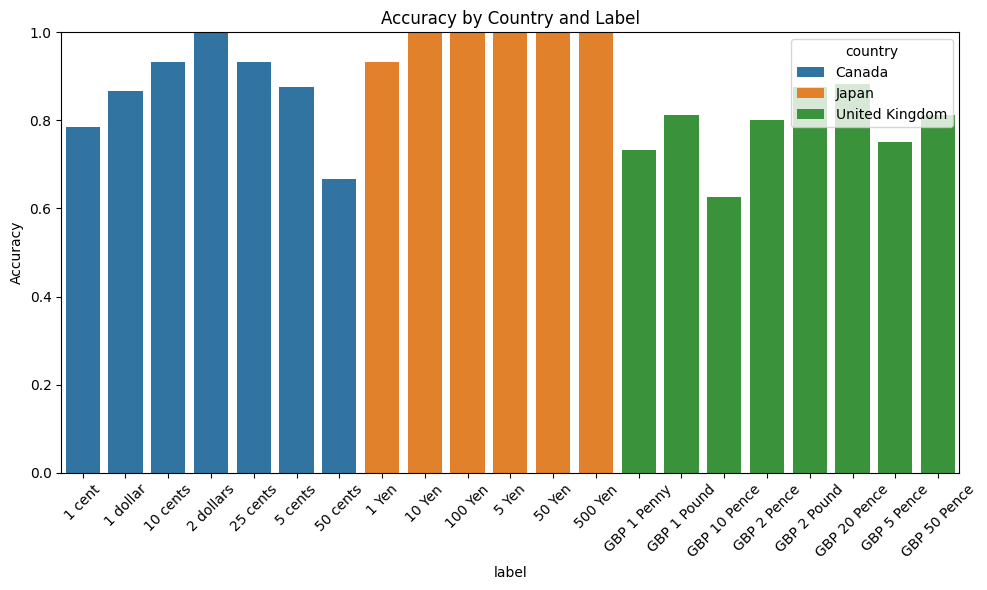

In [ ]:
evaluate_model(googlenet, test_loader, class_names)

misclassified = get_misclassified_images(googlenet, test_loader)
print(f"Total misclassified samples: {len(misclassified)}")
show_misclassified_images(misclassified, class_names, num_samples=6)

evaluated_df = get_evaluated_df(googlenet, test_loader, japan_canada_uk_test_df)
plot_grouped_accuracy(evaluated_df)

## Comparative Analysis of Fine-Grained Coin Classification Models

Eight models were trained and evaluated for the task of classifying coins from Japan, Canada, and the United Kingdom using fine-grained image classification techniques. Each model utilized both original and augmented data to improve robustness. Evaluation was based on overall classification accuracy as well as grouped accuracy by country and label.

### Model Variants

1. **ResNet18 – Full Fine-tune + ReduceLROnPlateau**
2. **GoogLeNet – Full Fine-tune + ReduceLROnPlateau**
3. **GoogLeNet – Partial Fine-tune (Last 2 Blocks + FC) + CosineAnnealingLR**
4. **GoogLeNet – Partial Fine-tune (Last 2 Blocks + FC) + ReduceLROnPlateau**
5. **ResNet18 – Partial Fine-tune + ReduceLROnPlateau + Original images + Augmented images**
6. **GoogLeNet – Full Fine-tune + CosineAnnealingLR + Original images + Augmented images**
7. **ResNet18 – Full Fine-tune + CosineAnnealingLR + Original images + Augmented images**
8. **GoogLeNet – Partial Fine-tune + CosineAnnealingLR + Original images + Augmented images**

### Performance Insights

- **Japanese coins consistently exhibited the highest classification accuracy across all models.** This can be attributed to their clear visual differences across denominations, making them more separable in a fine-grained classification setting.
  
- **Canadian and UK coins were more challenging to classify accurately.** These coins often share similar shapes, colors, and engraving patterns across denominations, which increases intra-class similarity and leads to misclassification.

### Model-Level Observations

- **GoogLeNet (Full Fine-tune)** models performed best overall, benefiting from multi-scale feature extraction via inception modules. These models demonstrated strong generalization across countries and labels, especially in fine-grained scenarios.

- **ResNet18 (Full Fine-tune)** models provided solid performance and fast convergence. They worked well with Japanese and Canadian coins but showed variability with UK denominations due to limited low-level feature separation.

- **GoogLeNet (Partial Fine-tune)** models performed competitively with reduced training time. While suitable for efficiency, they lacked the full flexibility needed to capture subtle class differences in UK and Canadian coins.

- **Models with ReduceLROnPlateau** generally adapted better to plateauing validation loss, especially for smaller datasets, whereas **CosineAnnealingLR** models showed smoother convergence but were more sensitive to class imbalance.

### Conclusion

Models performed best on Japanese coins due to clear visual separability across denominations. GoogLeNet models with full fine-tuning proved most effective for fine-grained classification. For applications prioritizing training speed or resource constraints, partial fine-tuning remains viable, albeit with some trade-off in label-level accuracy—especially for visually similar coin classes.
